# 🧠 03 · 3인자 학습 / R-STDP — eligibility trace 정식화

STDP는 타이밍 상관만 학습하므로 *목표*나 *보상*을 향해 학습할 수 없습니다. 여기에 **세 번째 인자**를 더한 것이 3인자 학습입니다.

$$ \underbrace{\Delta w_{ij}}_{\text{가중치 변화}} = \eta \cdot \underbrace{M(t)}_{\text{③ 신경조절/보상}} \cdot \underbrace{e_{ij}(t)}_{\text{①×② 자격 흔적}} $$

- $\eta$: 학습률.
- **① pre × ② post** → **eligibility trace(자격 흔적)** $e_{ij}$: "이 시냅스가 바뀔 *자격*이 있다"는 임시 표식.
- **③ 세 번째 인자** $M(t)$: 도파민 같은 전역 신호(보상, 오차). "지금 실제로 바꿔라"는 게이트.

## 왜 자격 흔적이 필요한가 — 지연 보상(distal reward) 문제
행동을 하고 **한참 뒤에야** 보상이 도착하는 경우(여러 행동을 한 뒤에야 성공/실패가 판명), 그 순간 "아까 어떤 시냅스가 기여했지?"를 알 수 없습니다. eligibility trace가 pre-post 상관을 **잠시 붙들어 두어**, 늦게 오는 보상과 과거 활동을 이어주는 **다리** 역할을 합니다.

## 이번 편 학습 목표
1. eligibility trace를 STDP로부터 **정식화**하고, 그 감쇠 시간상수가 지연 보상을 어떻게 견디는지 본다.
2. **R-STDP**로 지연 보상 하에서 **다중 행동 credit assignment**(어느 행동이 옳았나)를 학습한다.

In [1]:
import torch
import snntorch as snn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
device = torch.device("cpu")
print("torch:", torch.__version__, "| snntorch:", snn.__version__)

torch: 2.12.1 | snntorch: 1.0.0


## 1. 자격 흔적이 지연 보상을 잇는다 (결정적 데모)

시냅스 하나만 봅니다. $t=12$에서 pre가, $t=14$에서 post가 발화(pre가 먼저 → STDP상 LTP 자격)합니다. 이때 eligibility trace $e$에 양의 자격이 쌓이고, 이후 시간상수 $\tau_e$로 **천천히** 감쇠합니다.

핵심: 보상 $M$이 **언제 도착하느냐**에 따라 실제 가중치 변화 $\Delta w = \eta\, M\, e(t_r)$가 달라집니다. 흔적이 남아있는 동안 보상이 오면 학습되고, 너무 늦으면 흔적이 식어 학습이 안 됩니다. **$\tau_e$가 곧 "얼마나 지연된 보상까지 견디나"입니다.**

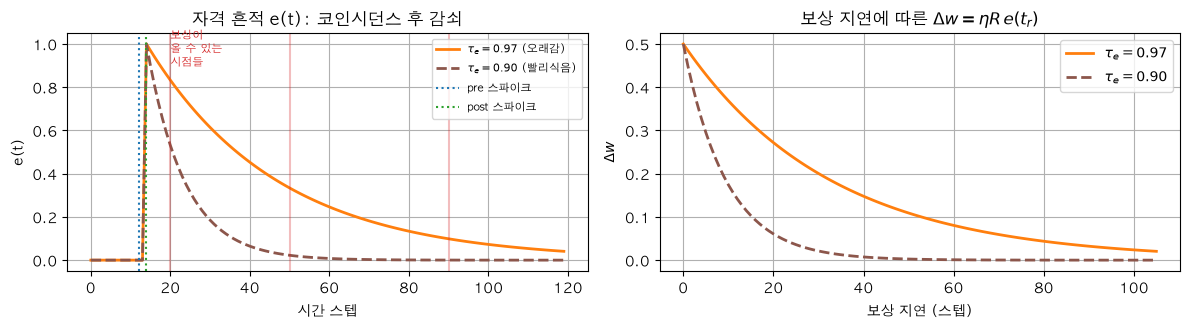

긴 흔적은 지연 40스텝에도 dw가 남지만, 짧은 흔적은 거의 0 -> tau_e가 '기다릴 수 있는 시간'을 정한다.


In [2]:
T = 120
pre_t, post_t = 12, 14                # pre가 먼저(자격 형성)
A_e = 1.0                             # 자격 형성 크기

def eligibility(tau_e):
    e = np.zeros(T)
    for t in range(1, T):
        e[t] = tau_e * e[t-1]
        if t == post_t:                # pre->post 코인시던스 순간 자격 적립
            e[t] += A_e
    return e

e_short = eligibility(0.90)           # 빨리 식음
e_long  = eligibility(0.97)           # 오래 감

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(e_long, color="tab:orange", lw=2, label=r"$\tau_e=0.97$ (오래감)")
ax[0].plot(e_short, color="tab:brown", lw=2, ls="--", label=r"$\tau_e=0.90$ (빨리식음)")
ax[0].axvline(pre_t, color="tab:blue", ls=":", label="pre 스파이크")
ax[0].axvline(post_t, color="tab:green", ls=":", label="post 스파이크")
for tr in [20, 50, 90]:
    ax[0].axvline(tr, color="tab:red", alpha=0.3)
ax[0].text(20, 0.9, "보상이\n올 수 있는\n시점들", color="tab:red", fontsize=8)
ax[0].set_title("자격 흔적 e(t): 코인시던스 후 감쇠"); ax[0].set_xlabel("시간 스텝"); ax[0].set_ylabel("e(t)"); ax[0].legend(fontsize=8)

# 보상 지연에 따른 dw
delays = np.arange(post_t, T)
eta, R = 0.5, 1.0
dw_long  = eta * R * e_long[delays]
dw_short = eta * R * e_short[delays]
ax[1].plot(delays - post_t, dw_long, color="tab:orange", lw=2, label=r"$\tau_e=0.97$")
ax[1].plot(delays - post_t, dw_short, color="tab:brown", lw=2, ls="--", label=r"$\tau_e=0.90$")
ax[1].set_title(r"보상 지연에 따른 $\Delta w = \eta R\, e(t_r)$"); ax[1].set_xlabel("보상 지연 (스텝)"); ax[1].set_ylabel(r"$\Delta w$"); ax[1].legend()
plt.tight_layout(); plt.show()
print("긴 흔적은 지연 40스텝에도 dw가 남지만, 짧은 흔적은 거의 0 -> tau_e가 '기다릴 수 있는 시간'을 정한다.")

## 2. R-STDP: 지연 보상으로 다중 행동 학습하기

**문맥(cue)을 보고 올바른 행동(action)을 고르는** 문제를, 정답 라벨 없이 보상만으로 학습합니다.

**셋업**
- 3개의 큐(cue) 그룹, 각 10개 입력 뉴런. 큐 $c$가 주어지면 그 그룹이 포아송 발화.
- 행동 뉴런 3개. 시행 동안 **탐험 잡음**을 넣어 다양한 행동을 시도.
- 선택된 행동 = 스파이크가 가장 많은 뉴런. 보상 $R=+1$(옳음)/$-1$(틀림)은 **시행이 끝난 뒤(지연)** 도착.
- 학습해야 할 정답 규칙: 큐 $c$ → 행동 $c$ (모델은 이걸 모름).

**핵심 두 가지**
1. **eligibility trace**가 시행 내내 pre-post 상관을 쌓아, 시행 끝의 지연 보상과 연결.
2. **credit은 실제로 *선택한* 행동에만** 준다 (policy-gradient식). 이게 없으면 보상이 무관한 뉴런까지 강화해 학습이 무너짐.

In [3]:
n_cue, per = 3, 10
n_in = n_cue*per; n_out = 3
in_rate, T = 0.5, 40
beta, thr = 0.9, 1.0
tau_pre = 0.85
lr, noise, w_max = 0.02, 0.4, 1.2

lif = snn.Leaky(beta=beta, threshold=thr, reset_mechanism="subtract")

def cue_input(c):
    spk = torch.zeros(T, n_in)
    spk[:, c*per:(c+1)*per] = (torch.rand(T, per) < in_rate).float()
    return spk

def trial(c, w, explore=True):
    mems = torch.zeros(n_out); xpre = torch.zeros(n_in)
    elig = torch.zeros(n_out, n_in); counts = torch.zeros(n_out)
    spk_in = cue_input(c)
    for t in range(T):
        cur = (w * spk_in[t]).sum(1)
        if explore: cur = cur + noise*torch.randn(n_out)     # 탐험
        s, mems = lif(cur, mems)
        xpre = tau_pre*xpre + spk_in[t]
        elig += s.unsqueeze(1) * xpre.unsqueeze(0)           # ①x② 자격 누적
        counts += s
    return elig, counts

w = torch.full((n_out, n_in), 0.15)
baseline = 0.0
acc_hist, wsnap = [], []
run_correct = []
n_trials = 2500
for tr in range(n_trials):
    c = np.random.randint(n_cue)
    elig, counts = trial(c, w, explore=True)
    action = int(counts.argmax()) if counts.max() > 0 else np.random.randint(n_out)
    R = 1.0 if action == c else -1.0
    mask = torch.zeros(n_out, 1); mask[action] = 1.0          # ③ x (선택한 행동에만)
    w = (w + lr*(R - baseline)*elig*mask).clamp(0.0, w_max)
    baseline = 0.95*baseline + 0.05*R
    run_correct.append(float(action == c))
    if tr % 25 == 0 and tr > 100:
        acc_hist.append((tr, np.mean(run_correct[-100:])))
    if tr in (0, 200, 600, n_trials-1): wsnap.append((tr, w.clone()))

# 탐험 없이 평가
ev = []
for c in range(n_cue):
    for _ in range(100):
        _, counts = trial(c, w, explore=False)
        a = int(counts.argmax()) if counts.max() > 0 else -1
        ev.append(a == c)
print(f"최종 평가 정확도(탐험 off): {np.mean(ev):.2f}  (우연 = 0.33)")

최종 평가 정확도(탐험 off): 1.00  (우연 = 0.33)


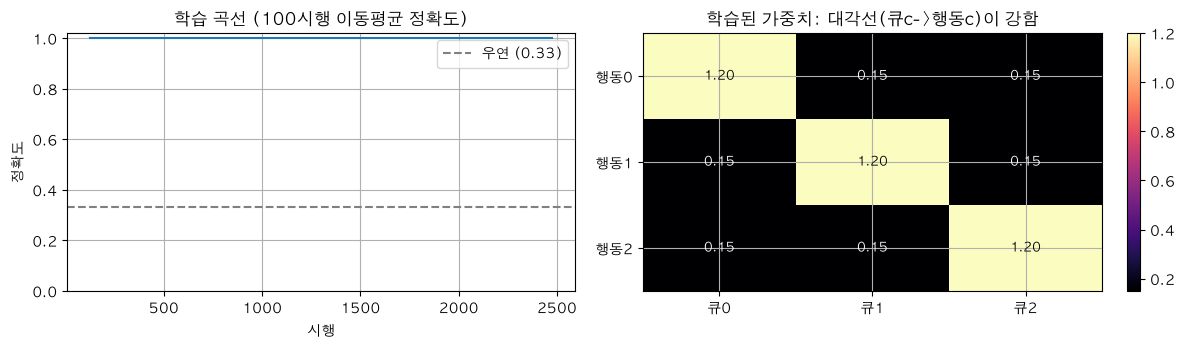

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
xs = [a[0] for a in acc_hist]; ys = [a[1] for a in acc_hist]
ax[0].plot(xs, ys, color="tab:blue")
ax[0].axhline(1/3, ls="--", c="gray", label="우연 (0.33)")
ax[0].set_ylim(0, 1.02); ax[0].set_title("학습 곡선 (100시행 이동평균 정확도)")
ax[0].set_xlabel("시행"); ax[0].set_ylabel("정확도"); ax[0].legend()

# 최종 '행동 x 큐' 평균 가중치 (대각선이 커야 학습된 것)
Wg = w.reshape(n_out, n_cue, per).mean(2).numpy()
im = ax[1].imshow(Wg, cmap="magma", aspect="auto")
ax[1].set_xticks(range(n_cue)); ax[1].set_xticklabels([f"큐{c}" for c in range(n_cue)])
ax[1].set_yticks(range(n_out)); ax[1].set_yticklabels([f"행동{o}" for o in range(n_out)])
for o in range(n_out):
    for c in range(n_cue):
        ax[1].text(c, o, f"{Wg[o,c]:.2f}", ha="center", va="center",
                   color="white" if Wg[o,c] < Wg.max()*0.6 else "black", fontsize=9)
ax[1].set_title("학습된 가중치: 대각선(큐c->행동c)이 강함")
plt.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()

## 3. 정리 & 다음 단계

### 배운 것
- **3인자 규칙**: $\Delta w = \eta\, M(t)\, e_{ij}$. ①×②가 **자격**을 만들고 ③(보상/신경조절)이 **게이트**한다.
- **eligibility trace**의 시간상수 $\tau_e$가 견딜 수 있는 **보상 지연**을 결정 — distal reward 문제의 해법.
- **credit assignment**: 보상은 *실제로 선택한 행동*에만 귀속시켜야 함(policy-gradient식). baseline $\bar R$을 빼 "기대보다 얼마나 좋았나"만 반영해 안정화.

### 직접 바꿔보면 좋은 것
- 2번 학습 루프에서 `mask`를 없애 **모든 행동에 credit**을 주면(→ `elig*mask` 를 `elig`로) 학습이 무너지는지 확인. (credit assignment의 중요성)
- `(R - baseline)`을 그냥 `R`로 바꿔 baseline(기대보상 $\bar R$)의 효과 확인.
- `noise`(탐험)를 `0.0`으로 → 탐험이 없으면 학습이 멈추는지.

### R-STDP의 한계 → 다음 편(`04`)
R-STDP의 세 번째 인자는 **스칼라 보상 하나**입니다. 뉴런 수천 개짜리 깊은/순환 네트워크에서 "각 뉴런이 최종 오차에 *얼마나* 기여했나"라는 정교한 credit은 스칼라 보상만으로는 부족합니다.

**e-prop**은 eligibility trace(지역)는 그대로 두되, 세 번째 인자를 **과제 오차로부터 유도한 뉴런별 learning signal**로 바꿉니다. 이 조합은 **BPTT의 지역·온라인 근사**로 유도됩니다. 다음 편에서 BPTT를 먼저 간단히 보고 e-prop으로 갑니다.